# Hand-eye view YOLO26m Segmentation Fine-tuning Pipeline

목표: Roboflow에서 병합/augmentation까지 완료한 hand-eye view speed stack cup 데이터셋을 사용하여 **YOLOv26m-seg medium 모델만** 학습하고, validation/test 성능 평가와 정성적 segmentation 결과 이미지를 Google Drive에 저장합니다.

핵심 원칙:
- Roboflow에서 이미 augmentation을 적용한 dataset version을 사용한다고 가정합니다.
- 따라서 이 노트북의 추가 offline augmentation은 기본적으로 비활성화되어 있습니다.
- `best.pt`, validation/test 성능표, test prediction 이미지를 모두 Google Drive에 저장합니다.


1. Environment setup


In [1]:
!nvidia-smi

# Colab 기본 pandas 버전과 충돌하지 않도록 pandas는 2.2.2로 고정
!pip install -q -U ultralytics opencv-python-headless pycocotools pyyaml matplotlib openpyxl albumentations
!pip install -q "pandas==2.2.2"

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os
import json
import glob
import shutil
import yaml
import random

import cv2
import numpy as np
import pandas as pd
import torch
from PIL import Image as PILImage
from pycocotools import mask as mask_utils
from ultralytics import YOLO
from IPython.display import Image, display

print("pandas version:", pd.__version__)
print("torch cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mon May 18 04:31:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Global configuration

여기만 수정하면 전체 코드의 경로와 모델 크기를 수정 가능


In [2]:
# =========================
# User config
# =========================
# Roboflow COCO Segmentation export folder in Google Drive
DRIVE_DATASET = Path('/content/drive/MyDrive/hand-eye-view-speed-stack-cup.0518.coco-segmentation')

IMG_SIZE = 1280
EPOCHS = 250
PATIENCE = 60

# 학습할 모델 크기: medium만 학습
MODEL_SIZES = ['m']
MODEL_NAME_MAP = {
    'n': 'YOLOv26n-seg',
    's': 'YOLOv26s-seg',
    'm': 'YOLOv26m-seg',
    'l': 'YOLOv26l-seg',
}

# =========================
# Offline augmentation config
# =========================
# True: train split만 offline augmentation으로 복제/증강한 데이터셋을 만든 뒤 학습합니다.
# False: 기존 원본 YOLO dataset으로 학습합니다.
USE_OFFLINE_AUGMENTATION = False

# 원본 train 이미지 1장당 새 augmentation 이미지를 몇 장 만들지 설정합니다.
# 4이면 원본 1장 + 증강 4장 = train set 약 5배.
AUG_COPIES_PER_IMAGE = 0
AUG_FACTOR = 1 + AUG_COPIES_PER_IMAGE

# True이면 augmented dataset을 매번 새로 생성합니다.
# 중간에 끊겼다가 이어서 평가만 할 때는 False로 바꿔도 됩니다.
REBUILD_AUGMENTED_DATASET = True

# augmentation 결과도 Drive에 저장하고 싶으면 True
SAVE_AUGMENTED_DATASET_TO_DRIVE = False

# augmentation randomness 고정
AUG_SEED = 42

# A100 기준 자동 batch. OOM이 발생하면 8, 6, 4 같은 정수로 낮추세요.
TRAIN_BATCH = 0.70
EVAL_BATCH = 8
PRED_CONF = 0.25
PRED_IOU = 0.70

# 증강 실험은 기존 원본 실험과 가중치가 섞이면 안 되므로 기본값은 False입니다.
# 중간에 런타임이 끊긴 뒤 Drive에 저장된 best.pt로 평가만 다시 하고 싶으면 True로 바꾸세요.
SKIP_TRAIN_IF_DRIVE_BEST_EXISTS = False

# 전체 run folder를 zip으로 저장할지 여부
SAVE_RUN_ZIP = True

# =========================
# Local paths
# =========================
LOCAL_COCO_DIR = Path(f'/content/coco_dataset_{IMG_SIZE}')
YOLO_DATASET_DIR = Path(f'/content/hand_eye_view_yolo26_seg_{IMG_SIZE}')
DATA_YAML = YOLO_DATASET_DIR / 'data.yaml'

AUGMENTED_YOLO_DATASET_DIR = Path(f'/content/hand_eye_view_yolo26_seg_{IMG_SIZE}_augx{AUG_FACTOR}')
AUGMENTED_DATA_YAML = AUGMENTED_YOLO_DATASET_DIR / 'data.yaml'

RUN_PROJECT = Path('/content/runs/segment')
EVAL_PROJECT = Path('/content/runs/segment_eval')
PRED_PROJECT = Path('/content/runs/segment_predict')

# Drive 저장 폴더
# Roboflow에서 이미 augmentation을 적용한 dataset version을 학습한다고 가정합니다.
if USE_OFFLINE_AUGMENTATION:
    EXPERIMENT_TAG = f'local_augx{AUG_FACTOR}'
else:
    EXPERIMENT_TAG = 'roboflow_0518_medium'

DRIVE_SAVE_DIR = Path(f'/content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch{EPOCHS}_{EXPERIMENT_TAG}')

DRIVE_WEIGHTS_DIR = DRIVE_SAVE_DIR / 'weights'
DRIVE_RUNS_DIR = DRIVE_SAVE_DIR / 'runs_zip'
DRIVE_PRED_DIR = DRIVE_SAVE_DIR / 'predict_images'
DRIVE_TABLE_DIR = DRIVE_SAVE_DIR / 'tables'
DRIVE_AUG_DATASET_DIR = DRIVE_SAVE_DIR / 'augmented_dataset'

for d in [DRIVE_SAVE_DIR, DRIVE_WEIGHTS_DIR, DRIVE_RUNS_DIR, DRIVE_PRED_DIR, DRIVE_TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = 0 if torch.cuda.is_available() else 'cpu'

print('DRIVE_DATASET:', DRIVE_DATASET)
print('LOCAL_COCO_DIR:', LOCAL_COCO_DIR)
print('YOLO_DATASET_DIR:', YOLO_DATASET_DIR)
print('DATA_YAML:', DATA_YAML)
print('USE_OFFLINE_AUGMENTATION:', USE_OFFLINE_AUGMENTATION)
print('AUG_COPIES_PER_IMAGE:', AUG_COPIES_PER_IMAGE)
print('AUG_FACTOR:', AUG_FACTOR)
print('AUGMENTED_YOLO_DATASET_DIR:', AUGMENTED_YOLO_DATASET_DIR)
print('AUGMENTED_DATA_YAML:', AUGMENTED_DATA_YAML)
print('MODEL_SIZES:', MODEL_SIZES)
print('EPOCHS:', EPOCHS)
print('EXPERIMENT_TAG:', EXPERIMENT_TAG)
print('DRIVE_SAVE_DIR:', DRIVE_SAVE_DIR)
print('DEVICE:', DEVICE)

assert DRIVE_DATASET.exists(), f'Drive dataset not found: {DRIVE_DATASET}'


DRIVE_DATASET: /content/drive/MyDrive/hand-eye-view-speed-stack-cup.0518.coco-segmentation
LOCAL_COCO_DIR: /content/coco_dataset_1280
YOLO_DATASET_DIR: /content/hand_eye_view_yolo26_seg_1280
DATA_YAML: /content/hand_eye_view_yolo26_seg_1280/data.yaml
USE_OFFLINE_AUGMENTATION: False
AUG_COPIES_PER_IMAGE: 0
AUG_FACTOR: 1
AUGMENTED_YOLO_DATASET_DIR: /content/hand_eye_view_yolo26_seg_1280_augx1
AUGMENTED_DATA_YAML: /content/hand_eye_view_yolo26_seg_1280_augx1/data.yaml
MODEL_SIZES: ['m']
EPOCHS: 250
EXPERIMENT_TAG: roboflow_0518_medium
DRIVE_SAVE_DIR: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium
DEVICE: 0


## 3. Copy dataset from Drive to Colab local


In [3]:
RESET_LOCAL_COPY = True

if RESET_LOCAL_COPY and LOCAL_COCO_DIR.exists():
    shutil.rmtree(LOCAL_COCO_DIR)

if not LOCAL_COCO_DIR.exists():
    shutil.copytree(DRIVE_DATASET, LOCAL_COCO_DIR)

print('Copied dataset to:', LOCAL_COCO_DIR)
print('\nTop-level files/folders:')
for p in sorted(LOCAL_COCO_DIR.iterdir()):
    print(' -', p)

json_files = sorted(LOCAL_COCO_DIR.rglob('*.json'))
print('\nJSON files:', len(json_files))
for j in json_files:
    print(' -', j)


Copied dataset to: /content/coco_dataset_1280

Top-level files/folders:
 - /content/coco_dataset_1280/README.dataset.txt
 - /content/coco_dataset_1280/README.roboflow.txt
 - /content/coco_dataset_1280/test
 - /content/coco_dataset_1280/train
 - /content/coco_dataset_1280/valid

JSON files: 3
 - /content/coco_dataset_1280/test/_annotations.coco.json
 - /content/coco_dataset_1280/train/_annotations.coco.json
 - /content/coco_dataset_1280/valid/_annotations.coco.json


## 4. Check COCO dataset structure


In [4]:
POSSIBLE_SPLITS = ['train', 'valid', 'val', 'test']

split_jsons = {}
for split in POSSIBLE_SPLITS:
    ann_path = LOCAL_COCO_DIR / split / '_annotations.coco.json'
    if ann_path.exists():
        split_jsons[split] = ann_path

print('Found splits:')
for split, path in split_jsons.items():
    print(f' - {split}: {path}')

assert 'train' in split_jsons, 'train/_annotations.coco.json을 찾지 못했습니다.'
assert ('valid' in split_jsons) or ('val' in split_jsons), 'valid 또는 val annotation을 찾지 못했습니다.'

with open(split_jsons['train'], 'r') as f:
    train_data = json.load(f)

categories = sorted(train_data['categories'], key=lambda c: c['id'])
names = [c['name'] for c in categories]
cat_id_to_idx = {c['id']: i for i, c in enumerate(categories)}

print('\nClasses:', names)
print('cat_id_to_idx:', cat_id_to_idx)


Found splits:
 - train: /content/coco_dataset_1280/train/_annotations.coco.json
 - valid: /content/coco_dataset_1280/valid/_annotations.coco.json
 - test: /content/coco_dataset_1280/test/_annotations.coco.json

Classes: ['hand-eye-view-speed-stack-cup', 'fallen-cup', 'upright-cup']
cat_id_to_idx: {0: 0, 1: 1, 2: 2}


## 5. Convert COCO segmentation to YOLO segmentation


In [5]:
def find_image_path(split_dir: Path, file_name: str):
    """COCO json의 file_name과 실제 이미지 경로가 다를 수 있어서 보수적으로 찾습니다."""
    candidates = [
        split_dir / file_name,
        split_dir / Path(file_name).name,
    ]
    for p in candidates:
        if p.exists():
            return p

    matches = list(split_dir.rglob(Path(file_name).name))
    return matches[0] if matches else None


def polygon_area(poly):
    pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
    return abs(cv2.contourArea(pts))


def coco_seg_to_polygons(segmentation, width, height):
    """
    COCO segmentation을 polygon list로 변환합니다.
    - polygon format: [[x1,y1,x2,y2,...], ...]
    - RLE format: mask contour로 변환
    """
    polygons = []

    # COCO polygon format
    if isinstance(segmentation, list):
        for poly in segmentation:
            if isinstance(poly, list) and len(poly) >= 6:
                polygons.append(poly)
        return polygons

    # COCO RLE format
    if isinstance(segmentation, dict):
        rle = segmentation
        if isinstance(rle.get('counts'), list):
            rle = mask_utils.frPyObjects(rle, height, width)

        mask = mask_utils.decode(rle)
        if mask.ndim == 3:
            mask = np.any(mask, axis=2).astype(np.uint8)
        else:
            mask = mask.astype(np.uint8)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            if len(cnt) >= 3:
                poly = cnt.reshape(-1, 2).astype(float).flatten().tolist()
                if len(poly) >= 6:
                    polygons.append(poly)
        return polygons

    return polygons


def normalize_polygon(poly, width, height):
    """YOLO segmentation format용 0~1 정규화 좌표로 변환합니다."""
    values = []
    for x, y in zip(poly[0::2], poly[1::2]):
        x = max(0.0, min(1.0, float(x) / float(width)))
        y = max(0.0, min(1.0, float(y) / float(height)))
        values.extend([x, y])
    return values


RESET_YOLO_DATASET = True
if RESET_YOLO_DATASET and YOLO_DATASET_DIR.exists():
    shutil.rmtree(YOLO_DATASET_DIR)

YOLO_DATASET_DIR.mkdir(parents=True, exist_ok=True)

conversion_summary = {}

for split, ann_path in split_jsons.items():
    print(f'\nConverting split: {split}')

    split_dir = LOCAL_COCO_DIR / split
    out_img_dir = YOLO_DATASET_DIR / 'images' / split
    out_label_dir = YOLO_DATASET_DIR / 'labels' / split
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_label_dir.mkdir(parents=True, exist_ok=True)

    with open(ann_path, 'r') as f:
        data = json.load(f)

    images = {img['id']: img for img in data['images']}
    anns_by_image = {img_id: [] for img_id in images.keys()}
    for ann in data['annotations']:
        anns_by_image.setdefault(ann['image_id'], []).append(ann)

    converted_images = 0
    converted_objects = 0
    skipped_objects = 0
    missing_images = 0

    for img_id, img in images.items():
        file_name = Path(img['file_name']).name
        src_img_path = find_image_path(split_dir, img['file_name'])

        if src_img_path is None:
            print('Image not found, skip:', img['file_name'])
            missing_images += 1
            continue

        dst_img_path = out_img_dir / file_name
        shutil.copy2(src_img_path, dst_img_path)

        width = img.get('width')
        height = img.get('height')
        if width is None or height is None:
            with PILImage.open(src_img_path) as im:
                width, height = im.size

        label_lines = []

        for ann in anns_by_image.get(img_id, []):
            category_id = ann['category_id']
            if category_id not in cat_id_to_idx:
                skipped_objects += 1
                continue

            cls_idx = cat_id_to_idx[category_id]
            segmentation = ann.get('segmentation', [])
            polygons = coco_seg_to_polygons(segmentation, width, height)

            if len(polygons) == 0:
                skipped_objects += 1
                continue

            # 한 객체에 polygon이 여러 개 있으면 가장 큰 polygon만 사용
            polygons = sorted(polygons, key=polygon_area, reverse=True)
            poly = polygons[0]

            if len(poly) < 6:
                skipped_objects += 1
                continue

            norm_coords = normalize_polygon(poly, width, height)
            if len(norm_coords) < 6:
                skipped_objects += 1
                continue

            line = str(cls_idx) + ' ' + ' '.join(f'{v:.6f}' for v in norm_coords)
            label_lines.append(line)
            converted_objects += 1

        label_path = out_label_dir / (Path(file_name).stem + '.txt')
        label_path.write_text('\n'.join(label_lines))
        converted_images += 1

    conversion_summary[split] = {
        'converted_images': converted_images,
        'converted_objects': converted_objects,
        'skipped_objects': skipped_objects,
        'missing_images': missing_images,
    }

    print(conversion_summary[split])

val_split = 'valid' if 'valid' in split_jsons else 'val'
yaml_data = {
    'path': str(YOLO_DATASET_DIR),
    'train': 'images/train',
    'val': f'images/{val_split}',
    'names': names,
}
if 'test' in split_jsons:
    yaml_data['test'] = 'images/test'

with open(DATA_YAML, 'w') as f:
    yaml.safe_dump(yaml_data, f, allow_unicode=True, sort_keys=False)

print('\nYOLO-seg dataset created at:', YOLO_DATASET_DIR)
print('\ndata.yaml:')
print(DATA_YAML.read_text())



Converting split: train
{'converted_images': 627, 'converted_objects': 2208, 'skipped_objects': 0, 'missing_images': 0}

Converting split: valid
{'converted_images': 60, 'converted_objects': 191, 'skipped_objects': 0, 'missing_images': 0}

Converting split: test
{'converted_images': 30, 'converted_objects': 91, 'skipped_objects': 0, 'missing_images': 0}

YOLO-seg dataset created at: /content/hand_eye_view_yolo26_seg_1280

data.yaml:
path: /content/hand_eye_view_yolo26_seg_1280
train: images/train
val: images/valid
names:
- hand-eye-view-speed-stack-cup
- fallen-cup
- upright-cup
test: images/test



## 6. Verify YOLO labels safely


In [6]:
def verify_yolo_seg_labels(yolo_dataset_dir: Path, split='train', show_n=3):
    label_files = sorted((yolo_dataset_dir / 'labels' / split).glob('*.txt'))
    non_empty = [p for p in label_files if p.read_text().strip()]

    print(f'[{split}] label file count:', len(label_files))
    print(f'[{split}] non-empty label count:', len(non_empty))

    if len(label_files) == 0:
        raise FileNotFoundError(f'No label txt files found: {yolo_dataset_dir / "labels" / split}')

    if len(non_empty) == 0:
        print('주의: 모든 label txt가 비어 있습니다. annotation 변환 또는 원본 COCO json을 확인하세요.')
        return None

    for sample_label in non_empty[:show_n]:
        lines = sample_label.read_text().strip().splitlines()
        print('\nSample label:', sample_label)
        print('first line:', lines[0])
        print('number of values:', len(lines[0].split()))
        if len(lines[0].split()) <= 5:
            print('주의: 값 개수가 5개 이하이면 segmentation polygon이 아니라 detection bbox 형식일 수 있습니다.')

    return non_empty

train_non_empty = verify_yolo_seg_labels(YOLO_DATASET_DIR, 'train')
val_non_empty = verify_yolo_seg_labels(YOLO_DATASET_DIR, val_split)

if (YOLO_DATASET_DIR / 'labels' / 'test').exists():
    test_non_empty = verify_yolo_seg_labels(YOLO_DATASET_DIR, 'test')
else:
    test_non_empty = None
    print('주의: test split이 없습니다. test 성능 평가는 건너뛰게 됩니다.')


[train] label file count: 627
[train] non-empty label count: 627

Sample label: /content/hand_eye_view_yolo26_seg_1280/labels/train/capture_20260504_151617_026_png.rf.8ee4f4beaac31a66ac68287450fefe37.txt
first line: 2 0.460156 0.493056 0.459375 0.494444 0.455469 0.494444 0.454688 0.495833 0.451562 0.495833 0.451562 0.497222 0.450781 0.498611 0.449219 0.498611 0.448437 0.500000 0.446875 0.500000 0.446094 0.501389 0.444531 0.501389 0.442969 0.504167 0.442188 0.504167 0.439063 0.509722 0.438281 0.509722 0.436719 0.512500 0.435937 0.512500 0.431250 0.520833 0.431250 0.523611 0.428125 0.529167 0.428125 0.530556 0.426563 0.533333 0.426563 0.534722 0.425781 0.536111 0.425781 0.538889 0.424219 0.541667 0.424219 0.544444 0.423438 0.545833 0.423438 0.548611 0.422656 0.550000 0.422656 0.558333 0.421875 0.559722 0.421875 0.562500 0.421094 0.563889 0.421094 0.569444 0.421875 0.570833 0.421875 0.575000 0.421094 0.576389 0.421094 0.583333 0.422656 0.586111 0.422656 0.595833 0.423438 0.597222 0.423438

## 7. Optional offline augmentation

현재 노트북은 Roboflow에서 이미 augmentation된 dataset version을 사용한다고 가정하므로 `USE_OFFLINE_AUGMENTATION=False`가 기본값입니다.

추가로 Albumentations 기반 offline augmentation을 한 번 더 적용하고 싶을 때만 `USE_OFFLINE_AUGMENTATION=True`로 변경하세요.


In [7]:
# =========================
# Offline augmentation for YOLO segmentation dataset
# =========================
import albumentations as A
import random
from pathlib import Path
import shutil
import yaml
import cv2
import numpy as np
import pandas as pd

random.seed(AUG_SEED)
np.random.seed(AUG_SEED)


def image_files_in(img_dir: Path):
    return sorted([
        p for p in img_dir.glob('*')
        if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']
    ])


def read_yolo_seg_label(label_path: Path):
    """YOLO segmentation txt를 읽어 [(class_id, normalized_polygon), ...] 형태로 반환합니다."""
    objects = []
    if not label_path.exists():
        return objects

    for line in label_path.read_text(encoding='utf-8').splitlines():
        parts = line.strip().split()
        if len(parts) < 7:
            continue

        cls = int(float(parts[0]))
        coords = np.array([float(x) for x in parts[1:]], dtype=np.float32)

        # x,y pair가 아니면 마지막 하나 제거
        if len(coords) % 2 == 1:
            coords = coords[:-1]

        if len(coords) < 6:
            continue

        poly = coords.reshape(-1, 2)
        poly = np.clip(poly, 0.0, 1.0)
        objects.append((cls, poly))

    return objects


def yolo_poly_to_mask(poly_norm, width, height):
    """normalized polygon을 binary mask로 변환합니다."""
    pts = poly_norm.copy()
    pts[:, 0] *= width
    pts[:, 1] *= height
    pts = np.round(pts).astype(np.int32)

    mask = np.zeros((height, width), dtype=np.uint8)
    if len(pts) >= 3:
        cv2.fillPoly(mask, [pts], 1)
    return mask


def mask_to_yolo_polygons(mask, width, height, min_area=20, epsilon_ratio=0.002):
    """
    binary mask를 YOLO segmentation polygon list로 변환합니다.
    한 instance에서 여러 contour가 생기면 가장 큰 contour를 사용합니다.
    """
    mask_u8 = (mask > 0).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return []

    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    contour = contours[0]
    area = cv2.contourArea(contour)

    if area < min_area:
        return []

    epsilon = epsilon_ratio * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)
    pts = approx.reshape(-1, 2).astype(np.float32)

    if len(pts) < 3:
        return []

    pts[:, 0] = np.clip(pts[:, 0] / width, 0.0, 1.0)
    pts[:, 1] = np.clip(pts[:, 1] / height, 0.0, 1.0)

    if len(pts) < 3:
        return []

    return [pts]


def write_yolo_seg_label(label_path: Path, objects):
    """[(class_id, normalized_polygon), ...]를 YOLO segmentation txt로 저장합니다."""
    lines = []
    for cls, poly in objects:
        if poly is None or len(poly) < 3:
            continue

        poly = np.asarray(poly, dtype=np.float32)
        poly = np.clip(poly, 0.0, 1.0)

        coords = []
        for x, y in poly:
            coords.append(f'{x:.6f}')
            coords.append(f'{y:.6f}')

        if len(coords) >= 6:
            lines.append(f'{cls} ' + ' '.join(coords))

    label_path.parent.mkdir(parents=True, exist_ok=True)
    label_path.write_text('\n'.join(lines), encoding='utf-8')
    return len(lines)


def make_offline_augmenter():
    """
    Albumentations 버전에 따라 일부 인자명이 다를 수 있어,
    가능한 보수적인 transform 위주로 구성합니다.
    """
    try:
        geom = A.ShiftScaleRotate(
            shift_limit=0.06,
            scale_limit=0.15,
            rotate_limit=10,
            border_mode=cv2.BORDER_CONSTANT,
            value=(114, 114, 114),
            mask_value=0,
            p=0.75,
        )
    except TypeError:
        geom = A.ShiftScaleRotate(
            shift_limit=0.06,
            scale_limit=0.15,
            rotate_limit=10,
            border_mode=cv2.BORDER_CONSTANT,
            fill=(114, 114, 114),
            fill_mask=0,
            p=0.75,
        )

    return A.Compose([
        A.HorizontalFlip(p=0.50),
        geom,
        A.Perspective(scale=(0.01, 0.04), keep_size=True, p=0.20),

        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.20, contrast_limit=0.20, p=1.0),
            A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=25, val_shift_limit=20, p=1.0),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
        ], p=0.80),

        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            A.MotionBlur(blur_limit=5, p=1.0),
            A.GaussNoise(p=1.0),
        ], p=0.25),

        A.ImageCompression(p=0.20),
    ])


def copy_split(src_root: Path, dst_root: Path, split: str):
    """images/split, labels/split을 그대로 복사합니다."""
    for sub in ['images', 'labels']:
        src = src_root / sub / split
        dst = dst_root / sub / split
        if dst.exists():
            shutil.rmtree(dst)
        shutil.copytree(src, dst)


def create_augmented_train_dataset(src_root: Path, dst_root: Path, aug_copies=4):
    """
    src_root: 원본 YOLO dataset
    dst_root: 증강 YOLO dataset
    valid/test는 원본 그대로, train은 원본 + augmentation으로 구성
    """
    if dst_root.exists() and REBUILD_AUGMENTED_DATASET:
        shutil.rmtree(dst_root)

    if dst_root.exists() and not REBUILD_AUGMENTED_DATASET:
        print('[SKIP] augmented dataset already exists:', dst_root)
        return

    print('Creating augmented dataset:', dst_root)

    # 디렉토리 생성
    for split in ['train', 'valid', 'test']:
        (dst_root / 'images' / split).mkdir(parents=True, exist_ok=True)
        (dst_root / 'labels' / split).mkdir(parents=True, exist_ok=True)

    # valid/test는 절대 증강하지 않고 원본 그대로 복사
    valid_split = 'valid' if (src_root / 'images' / 'valid').exists() else 'val'
    copy_split(src_root, dst_root, valid_split)
    if valid_split != 'valid':
        # data.yaml에서 val은 images/valid를 기대하므로 이름 통일
        if (dst_root / 'images' / 'valid').exists():
            shutil.rmtree(dst_root / 'images' / 'valid')
        if (dst_root / 'labels' / 'valid').exists():
            shutil.rmtree(dst_root / 'labels' / 'valid')
        shutil.move(str(dst_root / 'images' / valid_split), str(dst_root / 'images' / 'valid'))
        shutil.move(str(dst_root / 'labels' / valid_split), str(dst_root / 'labels' / 'valid'))

    if (src_root / 'images' / 'test').exists():
        copy_split(src_root, dst_root, 'test')
    else:
        print('[WARN] test split not found. test evaluation will fail unless data.yaml has test.')

    # train 원본 + 증강 생성
    src_img_dir = src_root / 'images' / 'train'
    src_lbl_dir = src_root / 'labels' / 'train'
    dst_img_dir = dst_root / 'images' / 'train'
    dst_lbl_dir = dst_root / 'labels' / 'train'

    augmenter = make_offline_augmenter()
    img_paths = image_files_in(src_img_dir)

    original_count = 0
    augmented_count = 0
    skipped_aug = 0
    original_objects = 0
    augmented_objects = 0

    for img_path in img_paths:
        label_path = src_lbl_dir / f'{img_path.stem}.txt'
        objects = read_yolo_seg_label(label_path)

        image = cv2.imread(str(img_path))
        if image is None:
            print('[WARN] failed to read image:', img_path)
            continue

        height, width = image.shape[:2]

        # 원본도 train set에 포함
        out_orig_img = dst_img_dir / img_path.name
        out_orig_lbl = dst_lbl_dir / f'{img_path.stem}.txt'
        shutil.copy2(img_path, out_orig_img)
        if label_path.exists():
            shutil.copy2(label_path, out_orig_lbl)
        else:
            out_orig_lbl.write_text('', encoding='utf-8')

        original_count += 1
        original_objects += len(objects)

        # instance별 mask 생성
        masks = [yolo_poly_to_mask(poly, width, height) for _, poly in objects]
        classes = [cls for cls, _ in objects]

        for k in range(aug_copies):
            aug_stem = f'{img_path.stem}_aug{k+1:02d}'

            if len(masks) > 0:
                augmented = augmenter(image=image, masks=masks)
                aug_img = augmented['image']
                aug_masks = augmented['masks']
            else:
                augmented = augmenter(image=image, masks=[])
                aug_img = augmented['image']
                aug_masks = []

            aug_h, aug_w = aug_img.shape[:2]
            aug_objects = []

            for cls, mask in zip(classes, aug_masks):
                polys = mask_to_yolo_polygons(mask, aug_w, aug_h, min_area=20)
                for poly in polys:
                    aug_objects.append((cls, poly))

            # 모든 객체가 사라진 경우에는 학습 안정성을 위해 저장하지 않음
            if len(objects) > 0 and len(aug_objects) == 0:
                skipped_aug += 1
                continue

            out_img_path = dst_img_dir / f'{aug_stem}.jpg'
            out_lbl_path = dst_lbl_dir / f'{aug_stem}.txt'

            cv2.imwrite(str(out_img_path), aug_img)
            n_labels = write_yolo_seg_label(out_lbl_path, aug_objects)

            augmented_count += 1
            augmented_objects += n_labels

    # data.yaml 생성
    with open(src_root / 'data.yaml', 'r', encoding='utf-8') as f:
        src_cfg = yaml.safe_load(f)

    new_cfg = dict(src_cfg)
    new_cfg['path'] = str(dst_root)
    new_cfg['train'] = 'images/train'
    new_cfg['val'] = 'images/valid'
    if (dst_root / 'images' / 'test').exists():
        new_cfg['test'] = 'images/test'

    with open(dst_root / 'data.yaml', 'w', encoding='utf-8') as f:
        yaml.safe_dump(new_cfg, f, sort_keys=False, allow_unicode=True)

    summary = {
        'original_train_images': original_count,
        'augmented_train_images': augmented_count,
        'total_train_images': original_count + augmented_count,
        'original_train_objects': original_objects,
        'augmented_train_objects': augmented_objects,
        'total_train_objects_approx': original_objects + augmented_objects,
        'skipped_augmented_images': skipped_aug,
        'aug_copies_per_image': aug_copies,
        'aug_factor_target': 1 + aug_copies,
    }

    summary_path = dst_root / 'augmentation_summary.yaml'
    with open(summary_path, 'w', encoding='utf-8') as f:
        yaml.safe_dump(summary, f, sort_keys=False, allow_unicode=True)

    print('\n========== AUGMENTATION SUMMARY ==========')
    for k, v in summary.items():
        print(f'{k}: {v}')

    print('saved:', dst_root / 'data.yaml')
    print('saved:', summary_path)


if USE_OFFLINE_AUGMENTATION:
    create_augmented_train_dataset(
        src_root=YOLO_DATASET_DIR,
        dst_root=AUGMENTED_YOLO_DATASET_DIR,
        aug_copies=AUG_COPIES_PER_IMAGE,
    )

    # 이후 학습/평가는 augmented dataset을 사용하도록 전역 변수 재지정
    YOLO_DATASET_DIR = AUGMENTED_YOLO_DATASET_DIR
    DATA_YAML = AUGMENTED_DATA_YAML

    print('\n[USE AUGMENTED DATASET]')
    print('YOLO_DATASET_DIR:', YOLO_DATASET_DIR)
    print('DATA_YAML:', DATA_YAML)

    if SAVE_AUGMENTED_DATASET_TO_DRIVE:
        DRIVE_AUG_DATASET_DIR.mkdir(parents=True, exist_ok=True)
        if DRIVE_AUG_DATASET_DIR.exists():
            # 기존 폴더 내부만 정리
            for child in DRIVE_AUG_DATASET_DIR.iterdir():
                if child.is_dir():
                    shutil.rmtree(child)
                else:
                    child.unlink()
        shutil.copytree(AUGMENTED_YOLO_DATASET_DIR, DRIVE_AUG_DATASET_DIR / AUGMENTED_YOLO_DATASET_DIR.name)
        print('copied augmented dataset to:', DRIVE_AUG_DATASET_DIR / AUGMENTED_YOLO_DATASET_DIR.name)
else:
    print('[USE ORIGINAL DATASET]')
    print('YOLO_DATASET_DIR:', YOLO_DATASET_DIR)
    print('DATA_YAML:', DATA_YAML)

# 최종 학습용 dataset 구조 확인
with open(DATA_YAML, 'r', encoding='utf-8') as f:
    final_cfg = yaml.safe_load(f)

print('\n========== FINAL DATA YAML ==========')
print(final_cfg)

final_root = Path(final_cfg['path'])
for split in ['train', 'valid', 'test']:
    img_dir = final_root / 'images' / split
    lbl_dir = final_root / 'labels' / split
    if img_dir.exists():
        n_img = len(image_files_in(img_dir))
        n_lbl = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
        print(f'{split}: images={n_img}, labels={n_lbl}, img_dir={img_dir}')


# Augmented dataset label sanity check
print('\n========== LABEL SANITY CHECK FOR FINAL DATASET ==========')
for _split in ['train', 'valid', 'test']:
    try:
        verify_yolo_seg_labels(YOLO_DATASET_DIR, split=_split, show_n=1)
    except Exception as e:
        print(f'[WARN] label verification failed for split={_split}: {e}')


[USE ORIGINAL DATASET]
YOLO_DATASET_DIR: /content/hand_eye_view_yolo26_seg_1280
DATA_YAML: /content/hand_eye_view_yolo26_seg_1280/data.yaml

========== FINAL DATA YAML ==========
{'path': '/content/hand_eye_view_yolo26_seg_1280', 'train': 'images/train', 'val': 'images/valid', 'names': ['hand-eye-view-speed-stack-cup', 'fallen-cup', 'upright-cup'], 'test': 'images/test'}
train: images=627, labels=627, img_dir=/content/hand_eye_view_yolo26_seg_1280/images/train
valid: images=60, labels=60, img_dir=/content/hand_eye_view_yolo26_seg_1280/images/valid
test: images=30, labels=30, img_dir=/content/hand_eye_view_yolo26_seg_1280/images/test

========== LABEL SANITY CHECK FOR FINAL DATASET ==========
[train] label file count: 627
[train] non-empty label count: 627

Sample label: /content/hand_eye_view_yolo26_seg_1280/labels/train/capture_20260504_151617_026_png.rf.8ee4f4beaac31a66ac68287450fefe37.txt
first line: 2 0.460156 0.493056 0.459375 0.494444 0.455469 0.494444 0.454688 0.495833 0.451562 

## 8. Train / validate / test / predict for YOLOv26m-seg medium only


In [8]:
# =========================
# Helper functions
# =========================
from pathlib import Path
import shutil
import time
import math
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
from IPython.display import Image, display

def run_name_for(size: str) -> str:
    return f'hand_eye_view_yolo26{size}_seg_{IMG_SIZE}_epoch{EPOCHS}_{EXPERIMENT_TAG}_a100'

def weight_name_for(size: str, kind='best') -> str:
    return f'{run_name_for(size)}_{kind}.pt'

def local_run_dir_for(size: str) -> Path:
    return RUN_PROJECT / run_name_for(size)

def local_best_for(size: str) -> Path:
    return local_run_dir_for(size) / 'weights' / 'best.pt'

def local_last_for(size: str) -> Path:
    return local_run_dir_for(size) / 'weights' / 'last.pt'

def drive_best_for(size: str) -> Path:
    return DRIVE_WEIGHTS_DIR / weight_name_for(size, 'best')

def drive_last_for(size: str) -> Path:
    return DRIVE_WEIGHTS_DIR / weight_name_for(size, 'last')

def safe_float(x):
    try:
        return float(np.asarray(x).mean())
    except Exception:
        try:
            return float(x)
        except Exception:
            return np.nan

def get_speed_dict(metrics):
    speed = getattr(metrics, 'speed', {}) or {}
    preprocess = safe_float(speed.get('preprocess', np.nan))
    inference = safe_float(speed.get('inference', np.nan))
    postprocess = safe_float(speed.get('postprocess', np.nan))
    total = preprocess + inference + postprocess

    if math.isnan(total) or total <= 0:
        fps_total = np.nan
    else:
        fps_total = 1000.0 / total

    if math.isnan(inference) or inference <= 0:
        fps_inference_only = np.nan
    else:
        fps_inference_only = 1000.0 / inference

    return {
        'preprocess_ms': preprocess,
        'inference_ms': inference,
        'postprocess_ms': postprocess,
        'total_ms': total,
        'fps_total': fps_total,
        'fps_inference_only': fps_inference_only,
    }

def get_model_stats(yolo_model, imgsz=1280):
    """
    모델 파라미터 수와 GFLOPs를 최대한 자동 추출합니다.
    GFLOPs는 Ultralytics 내부 함수/모델 info 반환 방식에 따라 추출되지 않을 수 있습니다.
    이 경우 val/train summary에 출력되는 GFLOPs 값을 참고하면 됩니다.
    """
    net = yolo_model.model

    params = sum(p.numel() for p in net.parameters())
    trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)

    gflops = np.nan

    try:
        from ultralytics.utils.torch_utils import get_flops
        flops_value = get_flops(net, imgsz=imgsz)
        if flops_value is not None:
            gflops = float(flops_value)
    except Exception:
        pass

    try:
        info = net.info(verbose=False, imgsz=imgsz)
        if isinstance(info, (list, tuple)) and len(info) >= 4:
            gflops = safe_float(info[-1])
        elif isinstance(info, str):
            import re
            m = re.search(r'([0-9.]+)\s*GFLOPs', info)
            if m:
                gflops = float(m.group(1))
    except Exception:
        pass

    return {
        'params': params,
        'params_M': params / 1e6,
        'trainable_params': trainable_params,
        'trainable_params_M': trainable_params / 1e6,
        'GFLOPs': gflops,
    }

def metrics_to_row(metrics, size, split, weight_path, stats):
    speed = get_speed_dict(metrics)

    row = {
        'model_size': size,
        'model': MODEL_NAME_MAP.get(size, f'YOLOv26{size}-seg'),
        'split': split,
        'weight': str(weight_path),
        'imgsz': IMG_SIZE,
        'epochs': EPOCHS,

        'params_M': stats.get('params_M', np.nan),
        'GFLOPs': stats.get('GFLOPs', np.nan),

        'box_P': safe_float(metrics.box.p),
        'box_R': safe_float(metrics.box.r),
        'box_mAP50': safe_float(metrics.box.map50),
        'box_mAP50_95': safe_float(metrics.box.map),

        'mask_P': safe_float(metrics.seg.p),
        'mask_R': safe_float(metrics.seg.r),
        'mask_mAP50': safe_float(metrics.seg.map50),
        'mask_mAP50_95': safe_float(metrics.seg.map),
    }

    row.update(speed)
    row['save_dir'] = str(getattr(metrics, 'save_dir', ''))
    return row

def copy_file_if_exists(src: Path, dst: Path):
    if src.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)
        print('saved:', dst)
        return True
    print('not found, skip:', src)
    return False

def zip_dir(src_dir: Path, zip_base: Path):
    if not src_dir.exists():
        print('run dir not found, skip zip:', src_dir)
        return None
    zip_base.parent.mkdir(parents=True, exist_ok=True)
    zip_path = shutil.make_archive(str(zip_base), 'zip', root_dir=str(src_dir))
    print('zipped:', zip_path)
    return zip_path

def get_test_image_dir():
    with open(DATA_YAML, 'r') as f:
        data_cfg = yaml.safe_load(f)

    assert 'test' in data_cfg, 'data.yaml에 test 항목이 없습니다.'
    dataset_root = Path(data_cfg['path'])
    test_img_dir = dataset_root / data_cfg['test']
    assert test_img_dir.exists(), f'test image dir not found: {test_img_dir}'
    return test_img_dir

def count_images(img_dir: Path):
    return len([p for p in img_dir.glob('*') if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']])

def save_dataframe(df: pd.DataFrame, name: str):
    csv_path = DRIVE_TABLE_DIR / f'{name}.csv'
    xlsx_path = DRIVE_TABLE_DIR / f'{name}.xlsx'
    df.to_csv(csv_path, index=False)
    df.to_excel(xlsx_path, index=False)
    print('saved:', csv_path)
    print('saved:', xlsx_path)
    return csv_path, xlsx_path

print('Helper functions ready.')


Helper functions ready.


In [9]:
# =========================
# Main loop: train -> save weights -> val/test eval -> predict all test images
# =========================
all_rows = []

test_img_dir = get_test_image_dir()
print('TEST_IMG_DIR:', test_img_dir)
print('test image count:', count_images(test_img_dir))

for size in MODEL_SIZES:
    print('\n' + '=' * 90)
    print(f'START MODEL: {MODEL_NAME_MAP[size]}  | size={size}')
    print('=' * 90)

    model_weights = f'yolo26{size}-seg.pt'
    run_name = run_name_for(size)
    run_dir = local_run_dir_for(size)
    best_model = local_best_for(size)
    last_model = local_last_for(size)
    drive_best = drive_best_for(size)
    drive_last = drive_last_for(size)

    print('model_weights:', model_weights)
    print('run_name:', run_name)
    print('run_dir:', run_dir)
    print('drive_best:', drive_best)

    # ------------------------------------------------------------
    # 1) Train or reuse saved best.pt
    # ------------------------------------------------------------
    if SKIP_TRAIN_IF_DRIVE_BEST_EXISTS and drive_best.exists():
        print(f'[SKIP TRAIN] Drive best.pt already exists: {drive_best}')
        best_model_for_eval = drive_best
    else:
        model = YOLO(model_weights)

        train_results = model.train(
            data=str(DATA_YAML),
            task='segment',

            epochs=EPOCHS,
            imgsz=IMG_SIZE,
            batch=TRAIN_BATCH,
            patience=PATIENCE,

            optimizer='auto',
            cos_lr=True,
            warmup_epochs=5.0,
            weight_decay=0.0005,

            overlap_mask=True,
            mask_ratio=2,

            hsv_h=0.015,
            hsv_s=0.45,
            hsv_v=0.30,
            degrees=5.0,
            translate=0.05,
            scale=0.30,
            shear=0.0,
            perspective=0.0003,
            flipud=0.0,
            fliplr=0.5,

            mosaic=0.30,
            close_mosaic=20,
            mixup=0.0,
            copy_paste=0.0,

            device=DEVICE,
            workers=8,
            amp=True,
            cache='ram',
            plots=True,
            save=True,
            save_period=10,

            project=str(RUN_PROJECT),
            name=run_name,
            exist_ok=True,
        )

        assert best_model.exists(), f'best.pt not found after training: {best_model}'

        copy_file_if_exists(best_model, drive_best)
        copy_file_if_exists(last_model, drive_last)

        if SAVE_RUN_ZIP:
            zip_dir(run_dir, DRIVE_RUNS_DIR / run_name)

        best_model_for_eval = drive_best if drive_best.exists() else best_model

    # ------------------------------------------------------------
    # 2) Load best model and extract model stats
    # ------------------------------------------------------------
    model = YOLO(str(best_model_for_eval))
    stats = get_model_stats(model, IMG_SIZE)
    print('model stats:', stats)

    # ------------------------------------------------------------
    # 3) Validation evaluation
    # ------------------------------------------------------------
    val_name = f'{run_name}_val'
    val_metrics = model.val(
        data=str(DATA_YAML),
        task='segment',
        imgsz=IMG_SIZE,
        batch=EVAL_BATCH,
        device=DEVICE,
        split='val',
        plots=True,
        project=str(EVAL_PROJECT),
        name=val_name,
        exist_ok=True,
    )
    val_row = metrics_to_row(val_metrics, size, 'val', best_model_for_eval, stats)
    all_rows.append(val_row)

    # ------------------------------------------------------------
    # 4) Test evaluation
    # ------------------------------------------------------------
    test_name = f'{run_name}_test'
    test_metrics = model.val(
        data=str(DATA_YAML),
        task='segment',
        imgsz=IMG_SIZE,
        batch=EVAL_BATCH,
        device=DEVICE,
        split='test',
        plots=True,
        project=str(EVAL_PROJECT),
        name=test_name,
        exist_ok=True,
    )
    test_row = metrics_to_row(test_metrics, size, 'test', best_model_for_eval, stats)
    all_rows.append(test_row)

    # ------------------------------------------------------------
    # 5) Predict all test images: instance segmentation + bbox
    # ------------------------------------------------------------
    pred_name = f'{run_name}_test_predict_all'
    pred_results = model.predict(
        source=str(test_img_dir),
        task='segment',
        imgsz=IMG_SIZE,
        conf=PRED_CONF,
        iou=PRED_IOU,
        device=DEVICE,
        save=True,
        save_txt=True,
        save_conf=True,
        retina_masks=True,
        project=str(PRED_PROJECT),
        name=pred_name,
        exist_ok=True,
    )

    pred_save_dir = Path(pred_results[0].save_dir)
    print('predict save dir:', pred_save_dir)

    # Drive에 정성적 결과 이미지 폴더 복사
    drive_pred_model_dir = DRIVE_PRED_DIR / pred_name
    if drive_pred_model_dir.exists():
        shutil.rmtree(drive_pred_model_dir)
    shutil.copytree(pred_save_dir, drive_pred_model_dir)
    print('copied predict results to:', drive_pred_model_dir)

    # ------------------------------------------------------------
    # 6) Save intermediate result table after each model
    # ------------------------------------------------------------
    df_all_intermediate = pd.DataFrame(all_rows)
    save_dataframe(df_all_intermediate, 'all_metrics_intermediate')

    print(f'FINISHED MODEL: {MODEL_NAME_MAP[size]}')

print('\nAll models finished.')


TEST_IMG_DIR: /content/hand_eye_view_yolo26_seg_1280/images/test
test image count: 30

START MODEL: YOLOv26m-seg  | size=m
model_weights: yolo26m-seg.pt
run_name: hand_eye_view_yolo26m_seg_1280_epoch250_roboflow_0518_medium_a100
run_dir: /content/runs/segment/hand_eye_view_yolo26m_seg_1280_epoch250_roboflow_0518_medium_a100
drive_best: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/weights/hand_eye_view_yolo26m_seg_1280_epoch250_roboflow_0518_medium_a100_best.pt
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=0.7, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/hand_eye_view_yolo26_seg_1280/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dn

In [10]:
# =========================
# Build final validation/test tables
# =========================
df_all = pd.DataFrame(all_rows)

# 보기 좋은 순서로 정렬
size_order = {'n': 0, 's': 1, 'm': 2, 'l': 3}
df_all['size_order'] = df_all['model_size'].map(size_order)
df_all = df_all.sort_values(['split', 'size_order']).drop(columns=['size_order']).reset_index(drop=True)

df_val = df_all[df_all['split'] == 'val'].copy().reset_index(drop=True)
df_test = df_all[df_all['split'] == 'test'].copy().reset_index(drop=True)

print('========== VALIDATION RESULT TABLE ==========')
display(df_val)

print('========== TEST RESULT TABLE ==========')
display(df_test)

save_dataframe(df_all, 'all_metrics_val_test')
save_dataframe(df_val, 'validation_metrics')
save_dataframe(df_test, 'test_metrics')

# 보고서에 넣기 좋은 compact table
compact_cols = [
    'model', 'split', 'params_M', 'GFLOPs',
    'box_P', 'box_R', 'box_mAP50', 'box_mAP50_95',
    'mask_P', 'mask_R', 'mask_mAP50', 'mask_mAP50_95',
    'inference_ms', 'total_ms', 'fps_total'
]

df_val_compact = df_val[compact_cols].copy()
df_test_compact = df_test[compact_cols].copy()

print('========== VALIDATION COMPACT TABLE ==========')
display(df_val_compact)

print('========== TEST COMPACT TABLE ==========')
display(df_test_compact)

save_dataframe(df_val_compact, 'validation_metrics_compact')
save_dataframe(df_test_compact, 'test_metrics_compact')


========== VALIDATION RESULT TABLE ==========


,model_size,model,split,weight,imgsz,epochs,params_M,GFLOPs,box_P,box_R,...,mask_R,mask_mAP50,mask_mAP50_95,preprocess_ms,inference_ms,postprocess_ms,total_ms,fps_total,fps_inference_only,save_dir
0,m,YOLOv26m-seg,val,/content/drive/MyDrive/hand_eye_view_yolo26m_s...,1280,250,26.973549,527.52384,0.97328,0.943997,...,0.930818,0.940951,0.9232,5.085894,12.555715,1.443841,19.085449,52.395937,79.645008,/content/runs/segment_eval/hand_eye_view_yolo2...


========== TEST RESULT TABLE ==========


,model_size,model,split,weight,imgsz,epochs,params_M,GFLOPs,box_P,box_R,...,mask_R,mask_mAP50,mask_mAP50_95,preprocess_ms,inference_ms,postprocess_ms,total_ms,fps_total,fps_inference_only,save_dir
0,m,YOLOv26m-seg,test,/content/drive/MyDrive/hand_eye_view_yolo26m_s...,1280,250,26.973549,527.52384,0.982308,0.961068,...,0.961068,0.97043,0.957333,8.975726,16.350288,1.621963,26.947978,37.108536,61.161001,/content/runs/segment_eval/hand_eye_view_yolo2...


saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/all_metrics_val_test.csv
saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/all_metrics_val_test.xlsx
saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/validation_metrics.csv
saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/validation_metrics.xlsx
saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/test_metrics.csv
saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/test_metrics.xlsx
========== VALIDATION COMPACT TABLE ==========


,model,split,params_M,GFLOPs,box_P,box_R,box_mAP50,box_mAP50_95,mask_P,mask_R,mask_mAP50,mask_mAP50_95,inference_ms,total_ms,fps_total
0,YOLOv26m-seg,val,26.973549,527.52384,0.97328,0.943997,0.974075,0.946817,0.982223,0.930818,0.940951,0.9232,12.555715,19.085449,52.395937


========== TEST COMPACT TABLE ==========


,model,split,params_M,GFLOPs,box_P,box_R,box_mAP50,box_mAP50_95,mask_P,mask_R,mask_mAP50,mask_mAP50_95,inference_ms,total_ms,fps_total
0,YOLOv26m-seg,test,26.973549,527.52384,0.982308,0.961068,0.972537,0.968079,0.982308,0.961068,0.97043,0.957333,16.350288,26.947978,37.108536


saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/validation_metrics_compact.csv
saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/validation_metrics_compact.xlsx
saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/test_metrics_compact.csv
saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/test_metrics_compact.xlsx


(PosixPath('/content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/test_metrics_compact.csv'),
 PosixPath('/content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/test_metrics_compact.xlsx'))

## 9. Optional: 기존 원본 데이터셋 실험과 증강 실험 비교

기존 원본 데이터셋 실험 결과가 Drive에 남아 있다면, 이 셀에서 자동으로 **원본 학습 결과 vs offline augmentation 학습 결과**를 비교합니다.


baseline_test_csv: /content/drive/MyDrive/hand_eye_view_yolo26_seg_result_epoch250/tables/test_metrics_compact.csv
exists: True

========== ORIGINAL vs AUGMENTED VAL COMPARE ==========


,model,params_M_original,GFLOPs_original,box_mAP50_95_original,mask_mAP50_95_original,mask_R_original,total_ms_original,fps_total_original,params_M_augmented,GFLOPs_augmented,box_mAP50_95_augmented,mask_mAP50_95_augmented,mask_R_augmented,total_ms_augmented,fps_total_augmented,delta_box_mAP50_95,delta_mask_mAP50_95,delta_mask_R,delta_fps_total
0,YOLOv26m-seg,26.97175,527.489434,0.898243,0.849765,0.857627,16.851711,59.341154,26.973549,527.52384,0.946817,0.9232,0.930818,19.085449,52.395937,0.048574,0.073435,0.07319,-6.945218


saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/original_vs_augmented_val_compare.csv
saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/original_vs_augmented_val_compare.xlsx

========== ORIGINAL vs AUGMENTED TEST COMPARE ==========


,model,params_M_original,GFLOPs_original,box_mAP50_95_original,mask_mAP50_95_original,mask_R_original,total_ms_original,fps_total_original,params_M_augmented,GFLOPs_augmented,box_mAP50_95_augmented,mask_mAP50_95_augmented,mask_R_augmented,total_ms_augmented,fps_total_augmented,delta_box_mAP50_95,delta_mask_mAP50_95,delta_mask_R,delta_fps_total
0,YOLOv26m-seg,26.97175,527.489434,0.933546,0.907493,0.944444,26.460892,37.791621,26.973549,527.52384,0.968079,0.957333,0.961068,26.947978,37.108536,0.034533,0.04984,0.016623,-0.683084


saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/original_vs_augmented_test_compare.csv
saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/original_vs_augmented_test_compare.xlsx


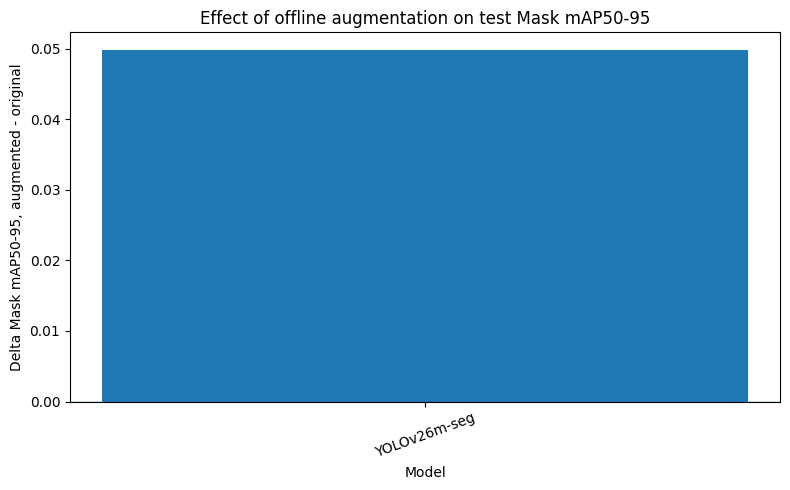

saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/original_vs_augmented_test_delta_mask_map.png


In [11]:
# =========================
# Optional baseline comparison: original dataset vs augmented dataset
# =========================
BASELINE_TABLE_DIR = Path(f'/content/drive/MyDrive/hand_eye_view_yolo26_seg_result_epoch{EPOCHS}/tables')
baseline_test_csv = BASELINE_TABLE_DIR / 'test_metrics_compact.csv'
baseline_val_csv = BASELINE_TABLE_DIR / 'validation_metrics_compact.csv'

print('baseline_test_csv:', baseline_test_csv)
print('exists:', baseline_test_csv.exists())

def compare_original_augmented(baseline_csv: Path, current_df: pd.DataFrame, split_name: str):
    if not baseline_csv.exists():
        print(f'[SKIP] baseline {split_name} csv not found:', baseline_csv)
        return None

    base_df = pd.read_csv(baseline_csv)
    aug_df = current_df.copy()

    keep_cols = [
        'model', 'params_M', 'GFLOPs',
        'box_mAP50_95', 'mask_mAP50_95',
        'mask_R', 'total_ms', 'fps_total'
    ]

    base_small = base_df[keep_cols].copy()
    aug_small = aug_df[keep_cols].copy()

    merged = base_small.merge(
        aug_small,
        on='model',
        suffixes=('_original', '_augmented'),
        how='inner'
    )

    for metric in ['box_mAP50_95', 'mask_mAP50_95', 'mask_R', 'fps_total']:
        merged[f'delta_{metric}'] = merged[f'{metric}_augmented'] - merged[f'{metric}_original']

    save_path = DRIVE_TABLE_DIR / f'original_vs_augmented_{split_name}_compare.csv'
    merged.to_csv(save_path, index=False)

    xlsx_path = DRIVE_TABLE_DIR / f'original_vs_augmented_{split_name}_compare.xlsx'
    merged.to_excel(xlsx_path, index=False)

    print(f'\n========== ORIGINAL vs AUGMENTED {split_name.upper()} COMPARE ==========')
    display(merged)
    print('saved:', save_path)
    print('saved:', xlsx_path)
    return merged

compare_val = compare_original_augmented(baseline_val_csv, df_val_compact, 'val')
compare_test = compare_original_augmented(baseline_test_csv, df_test_compact, 'test')

if compare_test is not None:
    # mask mAP50-95 변화량 bar plot
    plt.figure(figsize=(8, 5))
    plt.bar(compare_test['model'], compare_test['delta_mask_mAP50_95'])
    plt.axhline(0, linewidth=1)
    plt.xlabel('Model')
    plt.ylabel('Delta Mask mAP50-95, augmented - original')
    plt.title('Effect of offline augmentation on test Mask mAP50-95')
    plt.xticks(rotation=20)
    plt.tight_layout()
    delta_plot_path = DRIVE_TABLE_DIR / 'original_vs_augmented_test_delta_mask_map.png'
    plt.savefig(delta_plot_path, dpi=200)
    plt.show()
    print('saved:', delta_plot_path)


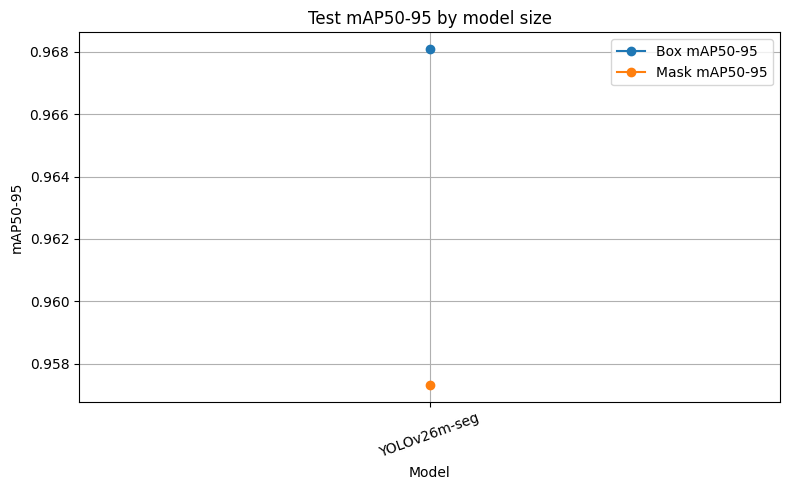

saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/test_map50_95_by_model.png


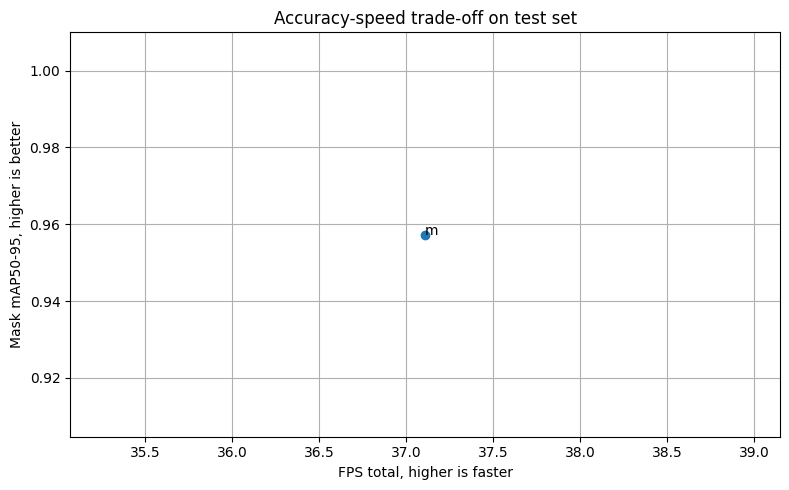

saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/test_accuracy_speed_tradeoff.png


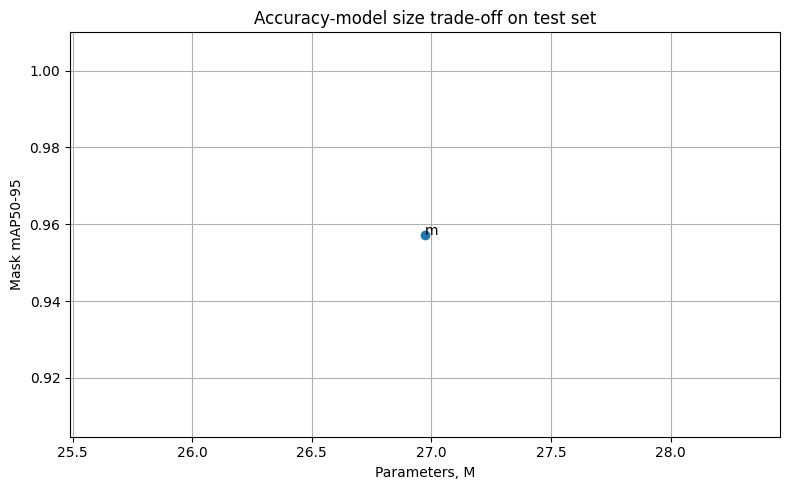

saved: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/tables/test_accuracy_model_size_tradeoff.png


In [12]:
# =========================
# Trade-off plots: accuracy vs speed/model size
# =========================
assert len(df_test) > 0, 'df_test가 비어 있습니다. 먼저 학습/평가 loop를 실행하세요.'

plot_df = df_test.copy()
plot_df = plot_df.sort_values('model_size', key=lambda s: s.map({'n':0, 's':1, 'm':2, 'l':3}))

# 1) 모델별 mask/box mAP50-95
plt.figure(figsize=(8, 5))
plt.plot(plot_df['model'], plot_df['box_mAP50_95'], marker='o', label='Box mAP50-95')
plt.plot(plot_df['model'], plot_df['mask_mAP50_95'], marker='o', label='Mask mAP50-95')
plt.xlabel('Model')
plt.ylabel('mAP50-95')
plt.title('Test mAP50-95 by model size')
plt.xticks(rotation=20)
plt.grid(True)
plt.legend()
plt.tight_layout()
map_plot_path = DRIVE_TABLE_DIR / 'test_map50_95_by_model.png'
plt.savefig(map_plot_path, dpi=200)
plt.show()
print('saved:', map_plot_path)

# 2) 정확도-속도 trade-off
plt.figure(figsize=(8, 5))
plt.scatter(plot_df['fps_total'], plot_df['mask_mAP50_95'])
for _, row in plot_df.iterrows():
    plt.annotate(row['model_size'], (row['fps_total'], row['mask_mAP50_95']))
plt.xlabel('FPS total, higher is faster')
plt.ylabel('Mask mAP50-95, higher is better')
plt.title('Accuracy-speed trade-off on test set')
plt.grid(True)
plt.tight_layout()
tradeoff_plot_path = DRIVE_TABLE_DIR / 'test_accuracy_speed_tradeoff.png'
plt.savefig(tradeoff_plot_path, dpi=200)
plt.show()
print('saved:', tradeoff_plot_path)

# 3) 모델 크기와 mask mAP50-95
plt.figure(figsize=(8, 5))
plt.scatter(plot_df['params_M'], plot_df['mask_mAP50_95'])
for _, row in plot_df.iterrows():
    plt.annotate(row['model_size'], (row['params_M'], row['mask_mAP50_95']))
plt.xlabel('Parameters, M')
plt.ylabel('Mask mAP50-95')
plt.title('Accuracy-model size trade-off on test set')
plt.grid(True)
plt.tight_layout()
size_plot_path = DRIVE_TABLE_DIR / 'test_accuracy_model_size_tradeoff.png'
plt.savefig(size_plot_path, dpi=200)
plt.show()
print('saved:', size_plot_path)


In [13]:
# =========================
# Automatic report-ready interpretation
# =========================
assert len(df_test) > 0, 'df_test가 비어 있습니다.'

def pct(x):
    if pd.isna(x):
        return 'N/A'
    return f'{x:.3f}'

best_mask = df_test.loc[df_test['mask_mAP50_95'].idxmax()]
best_box = df_test.loc[df_test['box_mAP50_95'].idxmax()]
fastest = df_test.loc[df_test['fps_total'].idxmax()]
smallest = df_test.loc[df_test['params_M'].idxmin()]

print('========== REPORT SUMMARY ==========')
print(f"Best mask mAP50-95 model: {best_mask['model']} | mask mAP50-95={pct(best_mask['mask_mAP50_95'])}, FPS={pct(best_mask['fps_total'])}")
print(f"Best box  mAP50-95 model: {best_box['model']} | box  mAP50-95={pct(best_box['box_mAP50_95'])}, FPS={pct(best_box['fps_total'])}")
print(f"Fastest model: {fastest['model']} | FPS={pct(fastest['fps_total'])}, mask mAP50-95={pct(fastest['mask_mAP50_95'])}")
print(f"Smallest model: {smallest['model']} | params={pct(smallest['params_M'])}M, mask mAP50-95={pct(smallest['mask_mAP50_95'])}")

print('\n========== MEDIUM MODEL DETAILED INTERPRETATION ==========')
medium_rows = df_test[df_test['model_size'] == 'm']
if len(medium_rows) > 0:
    m = medium_rows.iloc[0]
    print(
        f"YOLOv26m-seg 모델은 test set에서 "
        f"Box P={pct(m['box_P'])}, Box R={pct(m['box_R'])}, "
        f"Box mAP50={pct(m['box_mAP50'])}, Box mAP50-95={pct(m['box_mAP50_95'])}, "
        f"Mask P={pct(m['mask_P'])}, Mask R={pct(m['mask_R'])}, "
        f"Mask mAP50={pct(m['mask_mAP50'])}, Mask mAP50-95={pct(m['mask_mAP50_95'])}를 기록하였다."
    )
    print(
        f"추론 속도는 총 처리 시간 기준 {pct(m['total_ms'])} ms/image, "
        f"FPS={pct(m['fps_total'])}로 측정되었다."
    )
    print(
        "로봇팔 컵쌓기 task에서는 cup 중심점과 외곽 mask를 사용하므로 "
        "Box mAP보다 Mask mAP50-95와 Mask Recall을 더 중요하게 해석하는 것이 적절하다."
    )
else:
    print('medium 모델 결과가 없습니다.')

print('\n========== TRADE-OFF ANALYSIS ==========')
print(
    "모델 크기가 증가하면 일반적으로 파라미터 수와 연산량이 증가하여 추론 속도는 낮아질 수 있지만, "
    "복잡한 mask 경계와 겹친 컵을 더 안정적으로 구분할 가능성이 있다. "
    "최종 모델은 단순히 mAP가 가장 높은 모델이 아니라, Mask mAP50-95, Mask Recall, FPS, 모델 크기를 함께 고려하여 선택해야 한다."
)

# 보고서에 바로 붙여넣기 좋은 문단을 txt로 저장
report_txt = f"""
[보고서용 요약 문단]

본 실험에서는 hand-eye view 기반 speed stack 컵 인식을 위해 YOLOv26m-seg medium 모델을 동일한 데이터셋과 동일한 입력 해상도({IMG_SIZE}), epoch({EPOCHS}) 조건에서 fine-tuning하였다. 해당 모델은 validation set과 test set에 대해 bounding box 기준 Precision, Recall, mAP50, mAP50-95와 segmentation mask 기준 Precision, Recall, mAP50, mAP50-95를 측정하였다. 또한 실제 로봇팔 perception module 적용 가능성을 확인하기 위해 이미지당 preprocess, inference, postprocess 시간을 측정하고 FPS를 계산하였다.

Test set 기준 YOLOv26m-seg medium 모델은 Mask mAP50-95={pct(best_mask['mask_mAP50_95'])}, FPS={pct(best_mask['fps_total'])}를 기록하였다. 따라서 로봇팔 perception module 적용 시에는 segmentation 정확도와 실시간 추론 속도를 함께 고려해야 한다.
""".strip()

report_txt_path = DRIVE_TABLE_DIR / 'report_summary.txt'
report_txt_path.write_text(report_txt, encoding='utf-8')
print('\nSaved report summary to:', report_txt_path)
print('\n' + report_txt)


========== REPORT SUMMARY ==========
Best mask mAP50-95 model: YOLOv26m-seg | mask mAP50-95=0.957, FPS=37.109
Best box  mAP50-95 model: YOLOv26m-seg | box  mAP50-95=0.968, FPS=37.109
Fastest model: YOLOv26m-seg | FPS=37.109, mask mAP50-95=0.957
Smallest model: YOLOv26m-seg | params=26.974M, mask mAP50-95=0.957

========== MEDIUM MODEL DETAILED INTERPRETATION ==========
YOLOv26m-seg 모델은 test set에서 Box P=0.982, Box R=0.961, Box mAP50=0.973, Box mAP50-95=0.968, Mask P=0.982, Mask R=0.961, Mask mAP50=0.970, Mask mAP50-95=0.957를 기록하였다.
추론 속도는 총 처리 시간 기준 26.948 ms/image, FPS=37.109로 측정되었다.
로봇팔 컵쌓기 task에서는 cup 중심점과 외곽 mask를 사용하므로 Box mAP보다 Mask mAP50-95와 Mask Recall을 더 중요하게 해석하는 것이 적절하다.

========== TRADE-OFF ANALYSIS ==========
모델 크기가 증가하면 일반적으로 파라미터 수와 연산량이 증가하여 추론 속도는 낮아질 수 있지만, 복잡한 mask 경계와 겹친 컵을 더 안정적으로 구분할 가능성이 있다. 최종 모델은 단순히 mAP가 가장 높은 모델이 아니라, Mask mAP50-95, Mask Recall, FPS, 모델 크기를 함께 고려하여 선택해야 한다.

Saved report summary to: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoc


Qualitative results: YOLOv26m-seg
pred_dir: /content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_0518_medium/predict_images/hand_eye_view_yolo26m_seg_1280_epoch250_roboflow_0518_medium_a100_test_predict_all
prediction image count: 30
capture_20260504_151642_033_png.rf.75a06d8d1eaefd6576f4cd238e0b9901.jpg


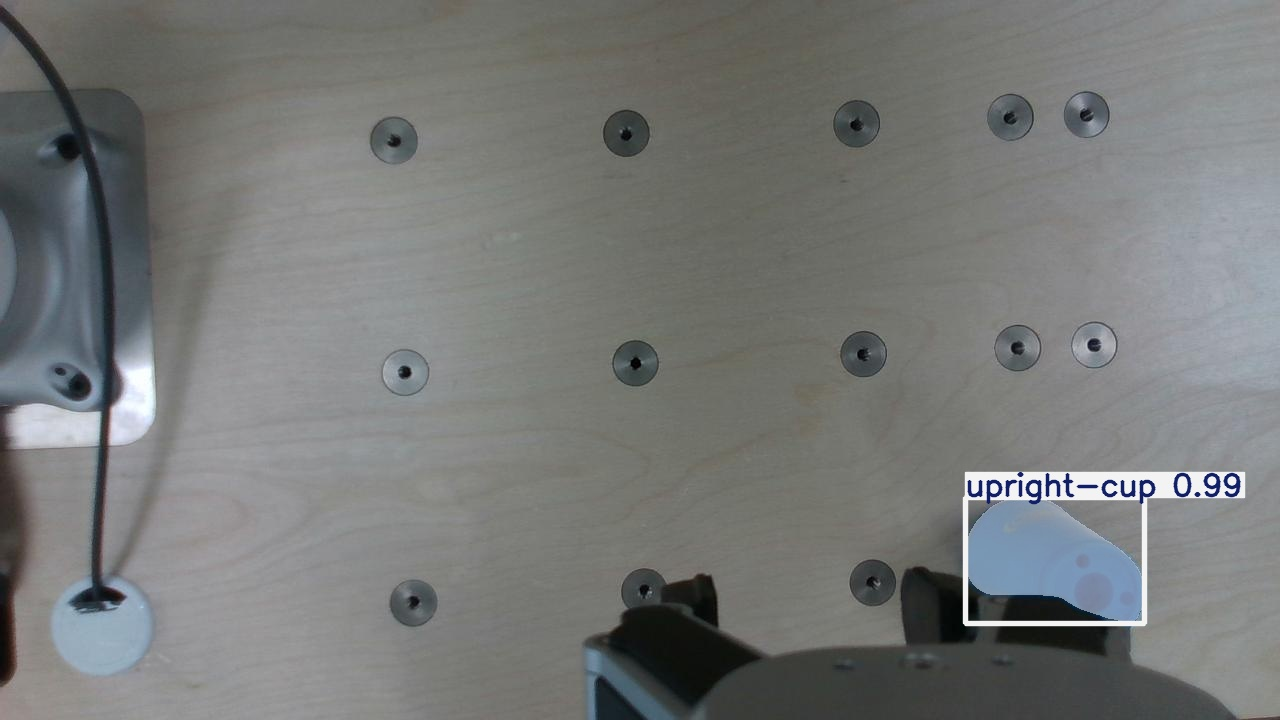

capture_20260504_151744_048_png.rf.da2be830a84798a01d39045383f49c18.jpg


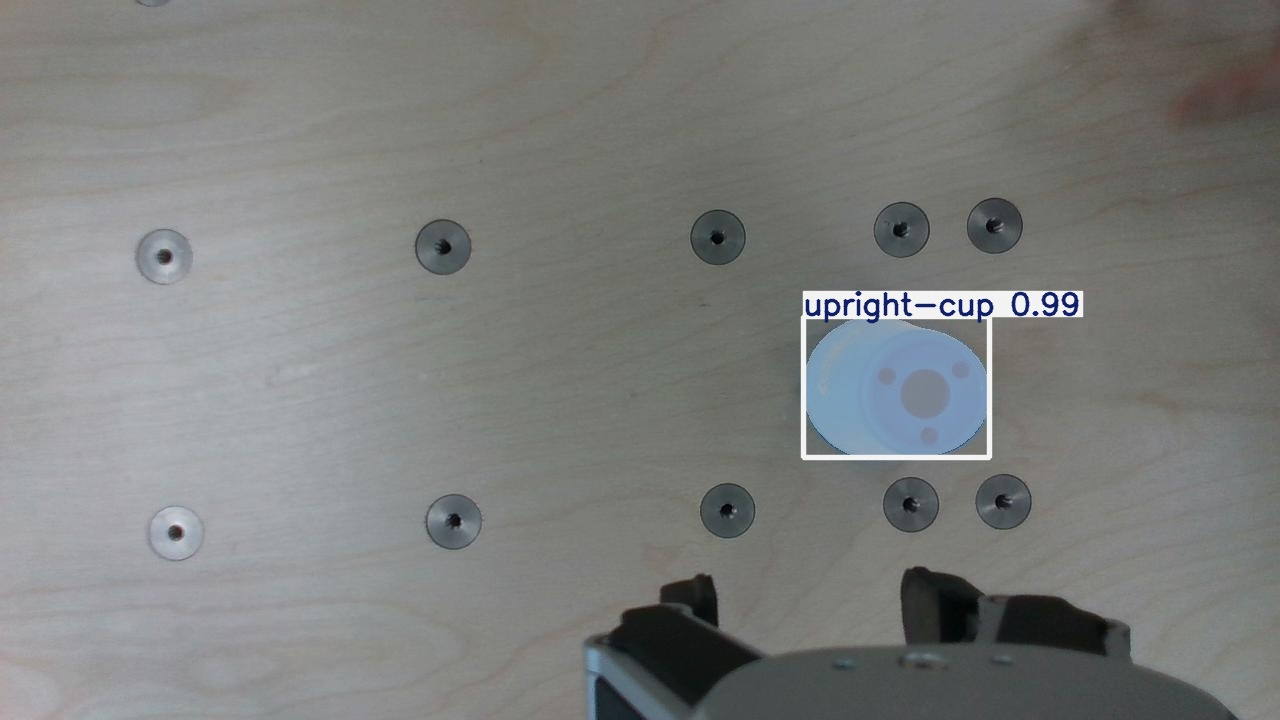

capture_20260504_151757_051_png.rf.c7fefdb46b8a8c927766f1dc9e80c882.jpg


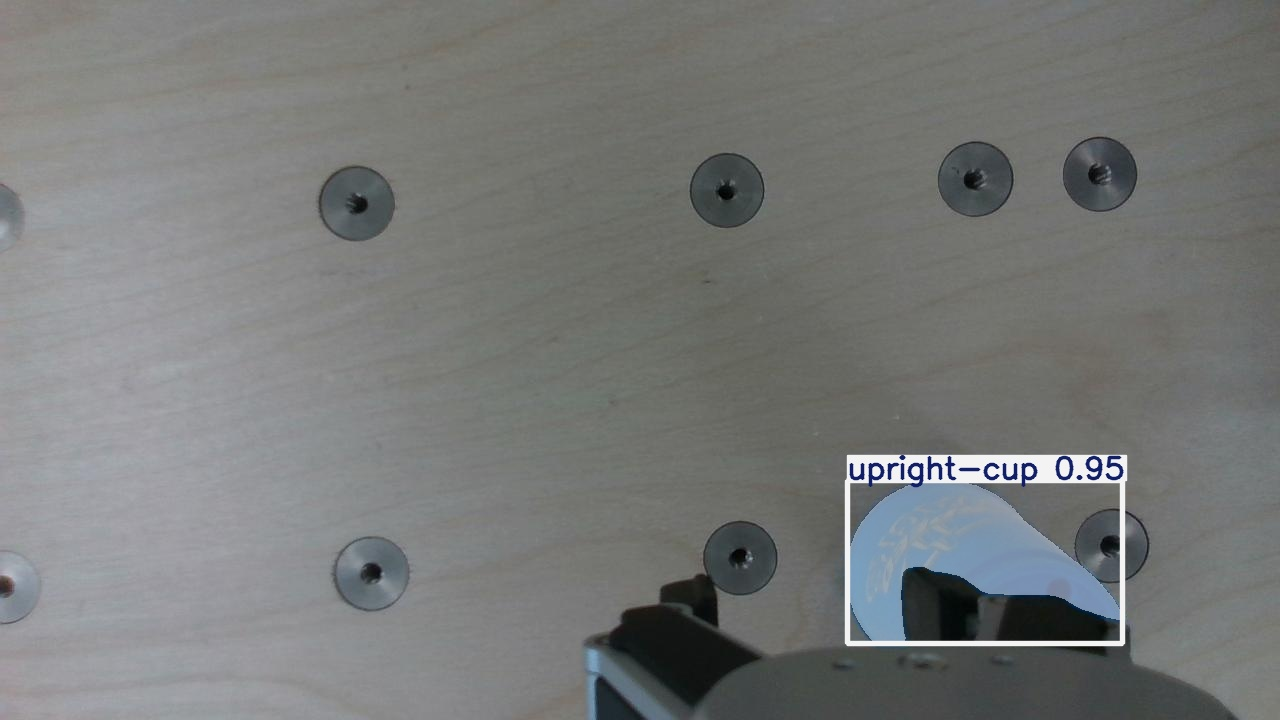

capture_20260504_151848_061_png.rf.358de662aabb1dfdb5c5e1e999f09dd6.jpg


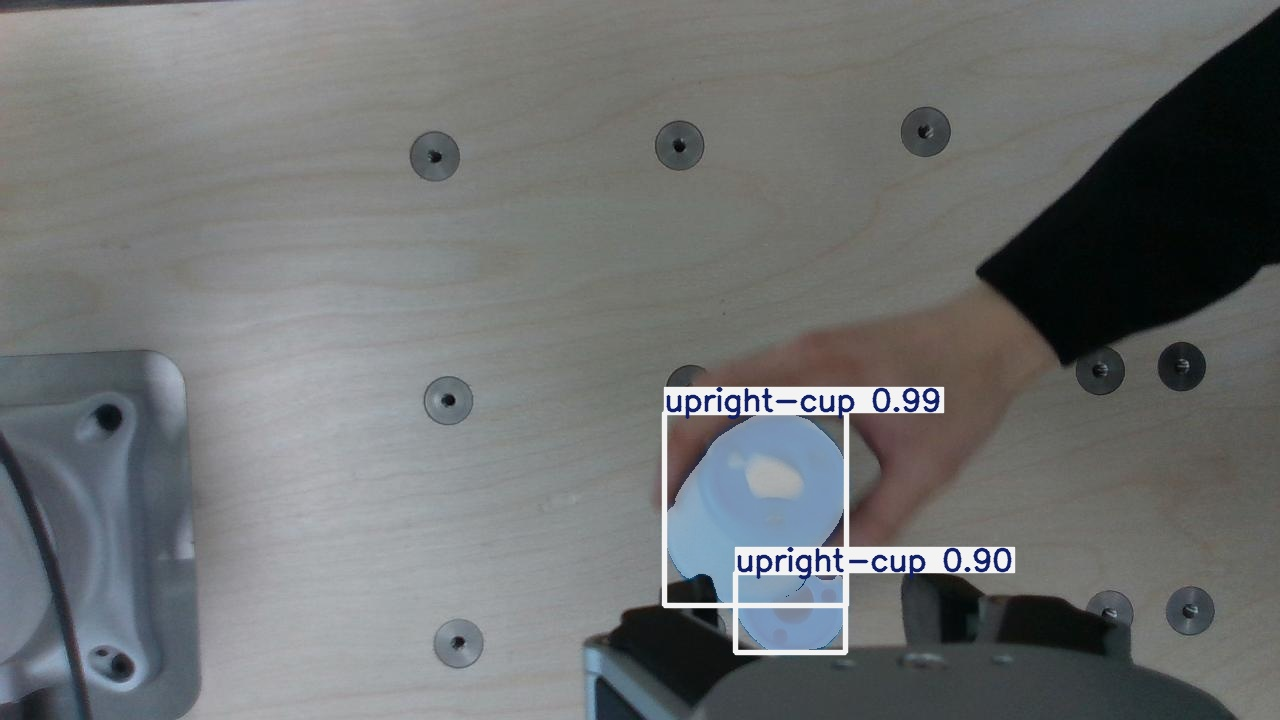

capture_20260504_151854_064_png.rf.3b98d0965263bee602a735dd04aecb14.jpg


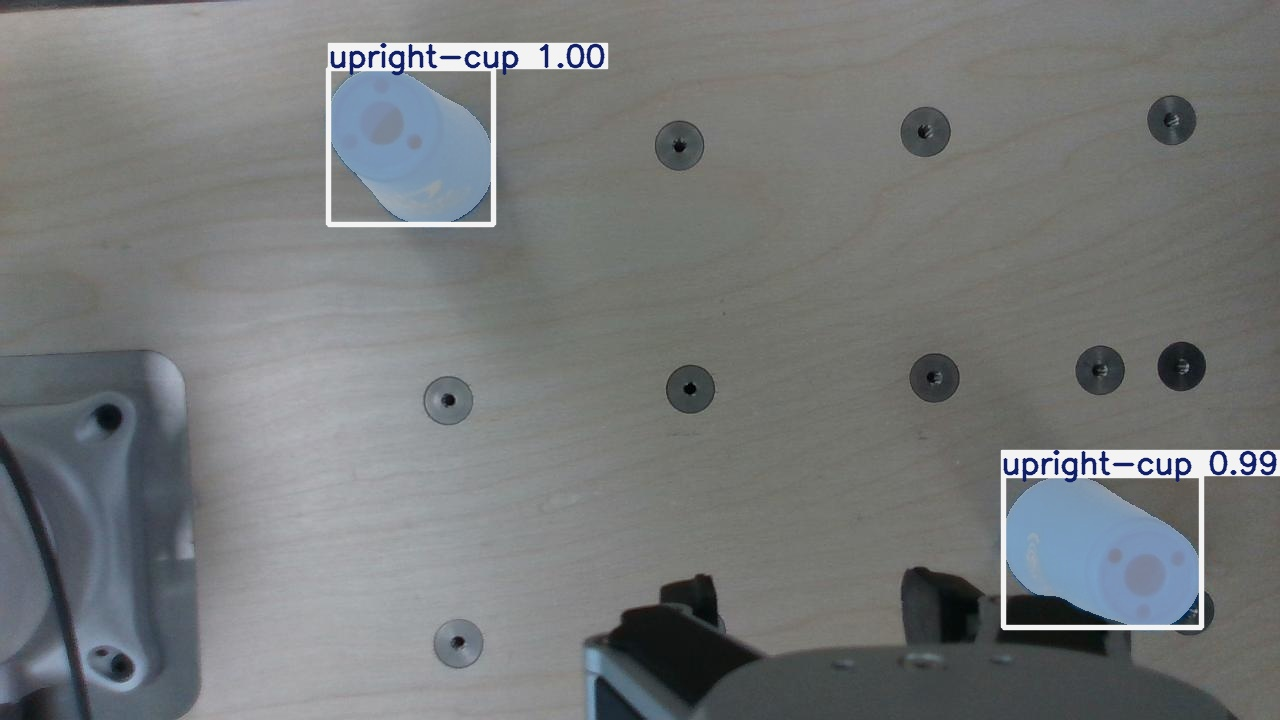

In [14]:
# =========================
# Display qualitative prediction images
# =========================
# 각 모델별 test prediction 결과 이미지 일부를 Colab에서 확인합니다.
# 전체 이미지는 DRIVE_PRED_DIR에 저장되어 있습니다.

MAX_DISPLAY_PER_MODEL = 5  # 전체를 보고 싶으면 999로 변경

for size in MODEL_SIZES:
    pred_name = f'{run_name_for(size)}_test_predict_all'
    pred_dir = DRIVE_PRED_DIR / pred_name

    print('\n' + '=' * 80)
    print(f'Qualitative results: {MODEL_NAME_MAP[size]}')
    print('pred_dir:', pred_dir)

    if not pred_dir.exists():
        print('prediction folder not found, skip.')
        continue

    image_files = sorted([
        p for p in pred_dir.glob('*')
        if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']
    ])

    print('prediction image count:', len(image_files))

    for img_path in image_files[:MAX_DISPLAY_PER_MODEL]:
        print(img_path.name)
        display(Image(filename=str(img_path), width=900))


## 9. 저장 위치 정리

실행이 끝나면 Google Drive의 아래 폴더에 결과가 저장됩니다.

```text
/content/drive/MyDrive/hand_eye_view_yolo26m_seg_result_epoch250_roboflow_aug_medium
```

주요 저장물은 다음과 같습니다.

```text
weights/
  hand_eye_view_yolo26m_seg_1280_epoch250_roboflow_aug_medium_a100_best.pt
  hand_eye_view_yolo26m_seg_1280_epoch250_roboflow_aug_medium_a100_last.pt

tables/
  validation_metrics.csv
  test_metrics.csv
  validation_metrics_compact.csv
  test_metrics_compact.csv
  all_metrics_val_test.csv
  report_summary.txt

predict_images/
  test 전체 이미지에 대한 instance segmentation + bbox 결과
```

보고서에는 `test_metrics_compact.csv`, `validation_metrics_compact.csv`, `report_summary.txt`, 그리고 `predict_images/`의 성공/실패 사례 이미지를 사용하면 됩니다.


## 10. 보고서 작성 시 해석 포인트

이 노트북의 결과는 기존 원본 데이터셋 실험과 비교하여 다음을 확인하기 위한 것입니다.

- offline augmentation으로 train set을 늘렸을 때 medium/large 모델의 test Mask mAP50-95가 개선되는가?
- large 모델이 여전히 small/nano보다 낮다면, 단순 데이터 수 부족 외에 label noise, test set 크기, hyperparameter 최적화 문제가 남아 있을 수 있습니다.
- validation/test set은 원본 그대로이므로, 성능 향상은 단순히 쉬운 augmented image를 맞힌 것이 아니라 원본 분포에 대한 일반화 성능 향상으로 해석할 수 있습니다.
